LİBRARY

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.datasets import ImageFolder
import os

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    ])

train_data = ImageFolder(root='C:/Users/Emirhan/Desktop/Pytorch ile derin öğrenme/Cnn/data/seg_train/seg_train', transform=transform)
test_data = ImageFolder(root='C:/Users/Emirhan/Desktop/Pytorch ile derin öğrenme/Cnn/data/seg_test/seg_test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


In [50]:
class PredictionDataset(Dataset):
    def __init__(self, root, transform=transform):
        self.root = root
        self.transform = transform
        self.image_files = [f for f in os.listdir(root) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        file = self.image_files[idx]
        image_path = os.path.join(self.root, file)

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, file

pred_data = PredictionDataset(root='C:/Users/Emirhan/Desktop/Pytorch ile derin öğrenme/Cnn/data/seg_pred/seg_pred', transform=transform)

pred_loader = DataLoader(pred_data, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


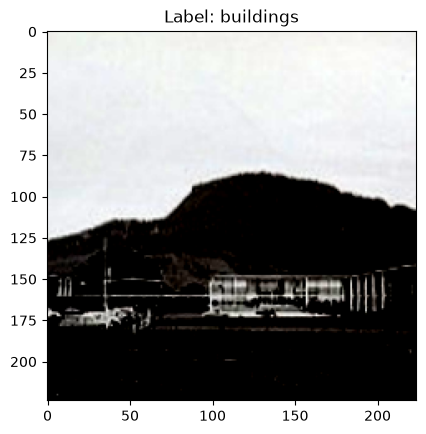

In [30]:
for i in range(1):    
    plt.figure()
    plt.imshow(np.transpose(train_data[i][0].numpy(), (1, 2, 0)))
    plt.title(f'Label: {train_data.classes[train_data[i][1]]}')
    plt.show()

In [38]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) #stride shift the window by 2 pixels
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=0.2) 
        self.fc1 = nn.Linear(64 * 56 * 56, 512) # 64 channels, 56x56 feature map size after pooling
        self.fc2 = nn.Linear(512, 6) # 6 classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool1(self.relu1(self.conv2(x)))
        x = x.view(-1, 64 * 56 * 56) # flatten the tensor for the fully connected layer
        x = self.dropout(self.relu1(self.fc1(x)))
        x = self.fc2(x)
        return x


Epoch [1/10], Loss: 0.1019
Epoch [2/10], Loss: 0.0728
Epoch [3/10], Loss: 0.0572
Epoch [4/10], Loss: 0.0417
Epoch [5/10], Loss: 0.0325
Epoch [6/10], Loss: 0.0233
Epoch [7/10], Loss: 0.0204
Epoch [8/10], Loss: 0.0196
Epoch [9/10], Loss: 0.0189
Epoch [10/10], Loss: 0.0176


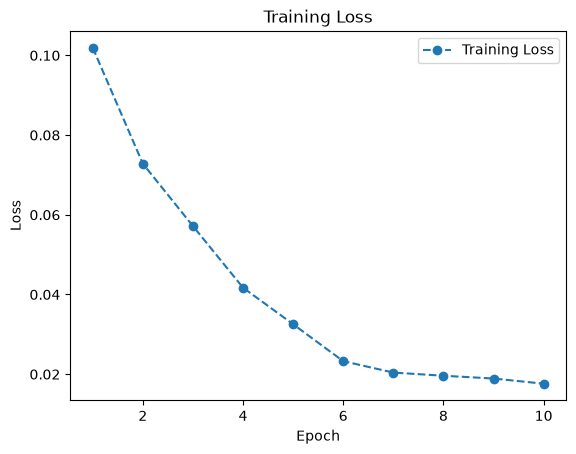

In [43]:
def train_model(model, train_loader, criterion, optimizer, epochs = 10):
    model.train()
    train_loss = []
    for epoch in range(epochs):
        run_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
        avg_loss = run_loss / len(train_loader)
        train_loss.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    plt.figure()
    plt.plot(range(1, epochs + 1), train_loss, marker = "o", linestyle = "--", label = "Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.show()


Accuracy of the model on the test images: 79.30%


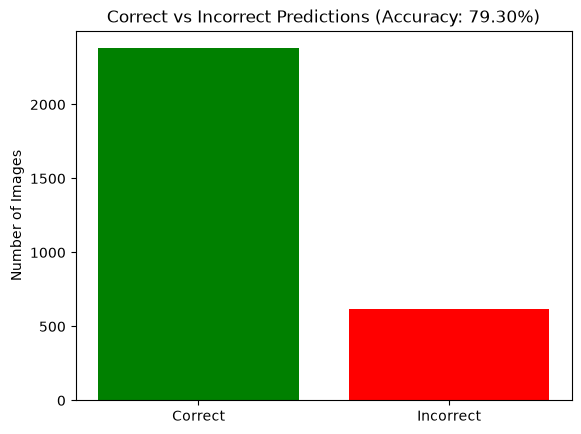

In [45]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')

    plt.figure()
    plt.bar(['Correct', 'Incorrect'], [correct, total - correct], color=['green', 'red'])
    plt.title(f'Correct vs Incorrect Predictions (Accuracy: {accuracy:.2f}%)')
    plt.ylabel('Number of Images')
    plt.show()


In [ ]:
if __name__ == "__main__":
    model = CNN().to(device)
    loss_and_optimizer = lambda model: (
    nn.CrossEntropyLoss(), 
    optim.SGD(model.parameters(), lr=0.001, momentum = 0.9)
    )
    train_model(model, train_loader, *loss_and_optimizer(model), epochs = 10)
    test_model(model, test_loader)
    

In [46]:
def predict(model, pred_loader, class_names, device):
    model.eval()  # Modeli çıkarım (inference) moduna al
    predictions = []

    with torch.no_grad():  # Gradyan hesaplamayı kapatarak VRAM tasarrufu yap
        for images, file_names in pred_loader:
            images = images.to(device)
            
            outputs = model(images)
            
            # En yüksek logit değerine sahip sınıfın indeksini al (dim=1)
            predicted_indices = torch.argmax(outputs, dim=1)

            # Sonuçları listeye ekle
            for file_name, pred_idx in zip(file_names, predicted_indices.cpu().numpy()):
                predictions.append({
                    "Image": file_name,
                    "Predicted_Label": class_names[pred_idx]
                })

    return pd.DataFrame(predictions)

In [51]:
# custom_dataset: Eğitimde kullandığın KaggleFolderDataset örneği
class_names = train_data.classes  # ['buildings', 'forest', 'glacier', ...]

# Tahminleri üret
df_results = predict(model, pred_loader, class_names, device)

# Sonuçları diske kaydet
df_results.to_csv("seg_pred_predictions.csv", index=False)

# İlk 10 tahmini incele
print(df_results.head(10))

       Image Predicted_Label
0  10004.jpg          street
1  10005.jpg        mountain
2  10012.jpg          street
3  10013.jpg        mountain
4  10017.jpg        mountain
5  10021.jpg          forest
6   1003.jpg             sea
7  10034.jpg         glacier
8  10038.jpg             sea
9  10040.jpg          street


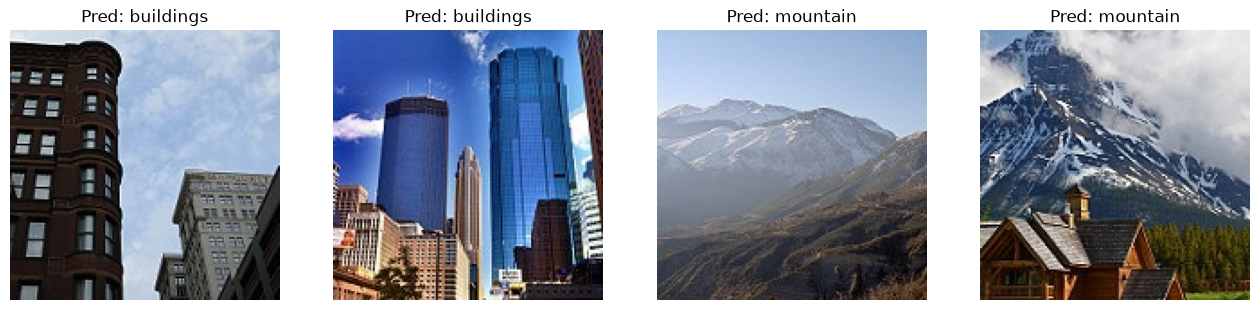

In [53]:
from PIL import Image

sample_preds = df_results.sample(4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, sample_preds.iterrows()):
    img_path = os.path.join(r"C:\Users\Emirhan\Desktop\Pytorch ile derin öğrenme\Cnn\data\seg_pred\seg_pred", row["Image"])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Pred: {row['Predicted_Label']}")
    ax.axis("off")
plt.show()